# Customer Churn Analysis

This notebook explores customer behavior and identifies patterns associated with customer churn. The analysis covers data quality, customer characteristics, services, billing information, and other factors that may be related to churn.

## Key Findings from Exploratory Data Analysis

The exploratory analysis revealed several patterns associated with customer churn:

- Customers who churn tend to have higher monthly charges.
- Fiber optic customers show a higher churn rate than DSL customers.
- Customers using electronic checks show a higher churn rate.
- Customers without technical support show higher churn.

In [1]:
import pandas as pd

print(pd.__version__)

3.0.6


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

## 1. Loading the Dataset

The dataset contains customer information including demographics, services, account details, charges, and churn status.

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Understanding the Dataset

Before performing any analysis, I first examine the size, structure, columns, and data types of the dataset.

In [5]:
df.shape

(7043, 33)

In [6]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## 3. Data Quality Checks

I check for missing values and duplicate customer records to identify potential data quality issues before analysis.

In [8]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [10]:
[col for col in df.columns if "churn" in col.lower()]

['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason']

In [11]:
[col for col in df.columns if "churn" in col.lower()]

['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason']

In [12]:
df["CustomerID"].duplicated().sum()

np.int64(0)

In [13]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

## 4. Target Variable Analysis

The target variable is customer churn. Understanding its distribution is important before building a predictive model.

In [14]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Observation

Approximately 26.5% of customers in the dataset have churned, while 73.5% remained. This indicates some class imbalance, which should be considered when evaluating machine learning models.

In [15]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [17]:
df_clean = df.copy()

In [18]:
pd.to_numeric(df_clean["Total Charges"], errors="coerce").isnull().sum()

np.int64(11)

In [19]:
problem_rows = df_clean[
    pd.to_numeric(df_clean["Total Charges"], errors="coerce").isnull()
]

problem_rows[
    ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,,No
2438,3115-CZMZD,0,20.25,,No
2568,5709-LVOEQ,0,80.85,,No
2667,4367-NUYAO,0,25.75,,No
2856,1371-DWPAZ,0,56.05,,No
4331,7644-OMVMY,0,19.85,,No
4687,3213-VVOLG,0,25.35,,No
5104,2520-SGTTA,0,20.00,,No
5719,2923-ARZLG,0,19.70,,No
6772,4075-WKNIU,0,73.35,,No


In [20]:
df_clean.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

## 5. Data Cleaning

The `Total Charges` column is stored as text rather than numeric data. Further inspection shows that 11 records contain blank values, all belonging to customers with zero months of tenure.

In [21]:
df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

df_clean["Total Charges"] = df_clean["Total Charges"].fillna(0)

In [22]:
df_clean["Total Charges"].isnull().sum()

np.int64(0)

### Cleaning Decision

Since these customers have zero months of tenure, the missing total charges were treated as zero rather than removing the customer records. The column was then converted to a numeric data type.

In [23]:
df_clean["Total Charges"].dtype

dtype('float64')

In [24]:
constant_columns = [
    col for col in df_clean.columns
    if df_clean[col].nunique() == 1
]

constant_columns

['Count', 'Country', 'State']

In [25]:
for col in constant_columns:
    print(col, ":", df_clean[col].unique())

Count : [1]
Country : <ArrowStringArray>
['United States']
Length: 1, dtype: str
State : <ArrowStringArray>
['California']
Length: 1, dtype: str


In [26]:
constant_columns

['Count', 'Country', 'State']

In [27]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Latitude",
    "Longitude"
]

df_clean = df_clean.drop(columns=columns_to_drop)

In [28]:
df_clean.shape

(7043, 26)

In [29]:
df_clean.shape

(7043, 26)

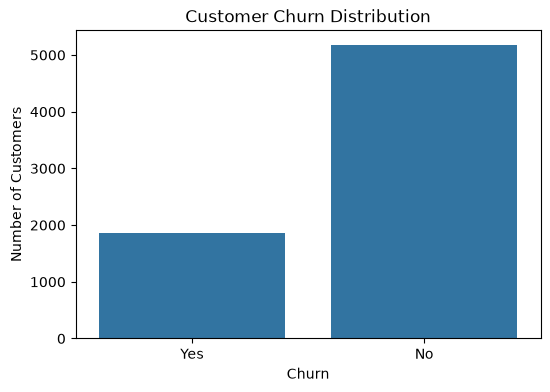

In [30]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## 6. Churn by Contract Type

This analysis examines whether churn behavior differs across month-to-month, one-year, and two-year contracts.

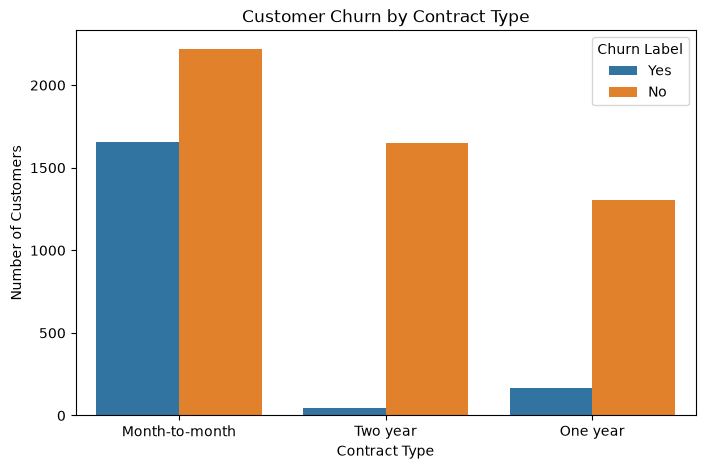

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn Label"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

### Observation

Churn varies substantially across contract types. Month-to-month customers show greater churn than customers with longer-term contracts, suggesting a strong association between contract duration and customer retention.

In [32]:
contract_churn = (
    df_clean.groupby("Contract")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
)

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn Value, dtype: float64

## 7. Customer Tenure and Churn

Customer tenure is analyzed to understand whether the length of the customer relationship is associated with churn.

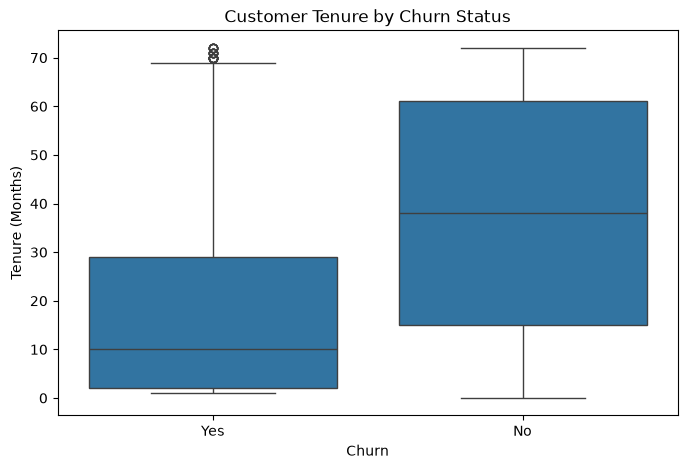

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Observation

Customers who churn generally have shorter tenure than customers who remain, suggesting that newer customers may represent an important retention segment.

## 8. Monthly Charges and Churn

This analysis compares monthly charges between customers who churned and those who remained.

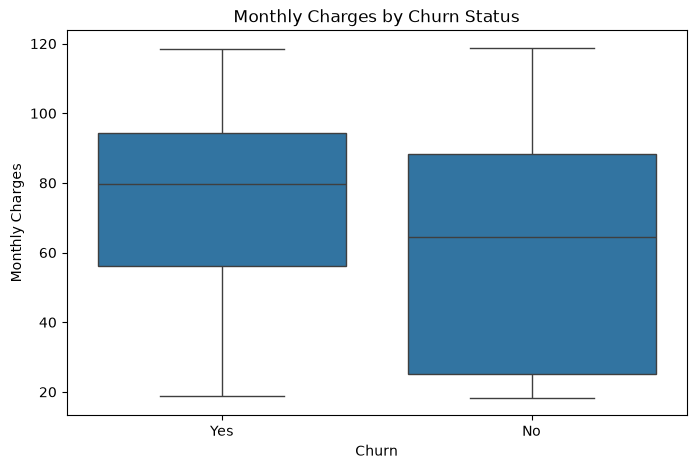

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Observation

Customers who churn tend to have higher monthly charges than customers who remain. However, this relationship is observational and does not establish that higher charges directly cause churn.

In [35]:
internet_churn = (
    df_clean.groupby("Internet Service")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
)

internet_churn

Internet Service
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn Value, dtype: float64

## 9. Internet Service and Churn

Churn rates are compared across different types of internet service.

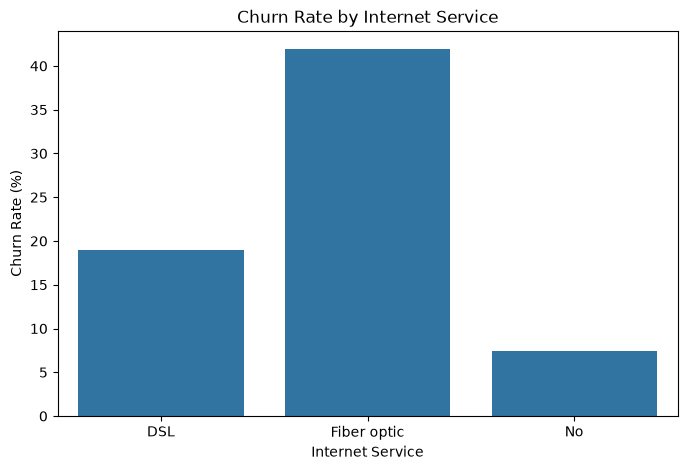

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

### Observation

Fiber optic customers show the highest churn rate, at roughly 42%, compared with approximately 19% for DSL customers. Customers without internet service show the lowest churn rate.

In [37]:
payment_churn = (
    df_clean.groupby("Payment Method")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

payment_churn

Payment Method
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn Value, dtype: float64

## 10. Payment Method and Churn

This section examines whether customer churn rates differ according to payment method.

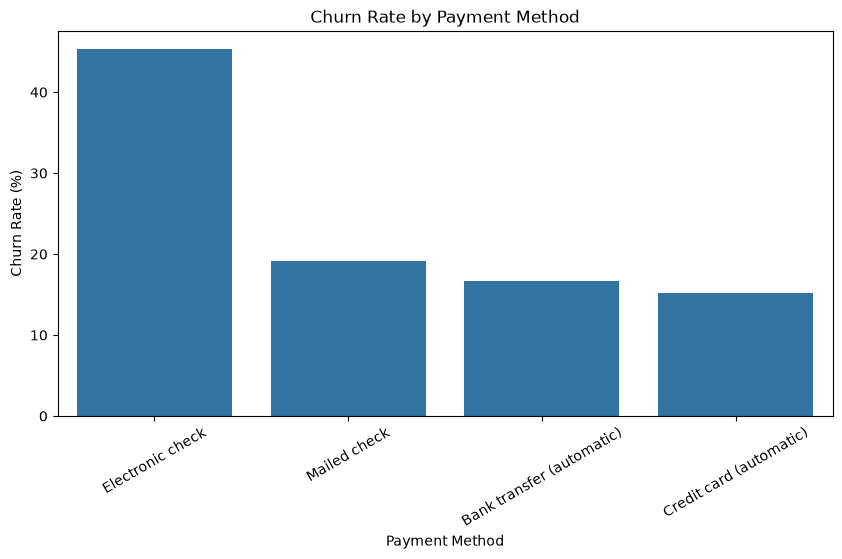

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

### Observation

Customers using electronic checks have a considerably higher churn rate than customers using the other payment methods. This makes payment method a potentially useful feature for churn prediction.

## 11. Technical Support and Churn

This analysis investigates the relationship between technical support services and customer churn.

In [39]:
support_churn = (
    df_clean.groupby("Tech Support")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
)

support_churn

Tech Support
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn Value, dtype: float64

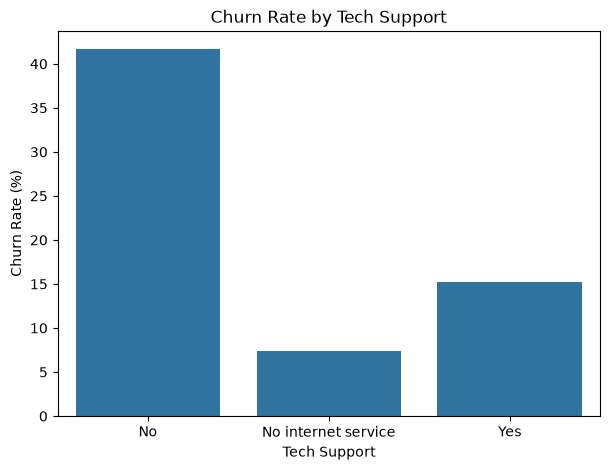

In [40]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=support_churn.index,
    y=support_churn.values
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.show()

### Observation

Customers without technical support show substantially higher churn than customers who have technical support. This suggests a strong association between support availability and customer retention.

In [41]:
df_clean.groupby("Churn Label")[
    ["Tenure Months", "Monthly Charges", "Total Charges"]
].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Churn Label,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


## 12. Key Findings

The exploratory analysis identified several important patterns:

- Approximately 26.5% of customers in the dataset churned.
- Month-to-month customers show higher churn than customers with longer contracts.
- Customers who churn generally have shorter tenure.
- Churned customers tend to have higher monthly charges.
- Fiber optic customers show a higher churn rate than DSL customers.
- Electronic check users have the highest churn rate among payment methods.
- Customers without technical support show considerably higher churn.

These findings describe associations in the available data and do not necessarily imply causal relationships. They provide useful directions for feature selection and predictive modeling.